In [1]:
print("hello")

hello


In [6]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [8]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv,description="Query arxiv papers")
print(arxiv.name)

arxiv


In [11]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [12]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [15]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [16]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

/tmp/ipykernel_246552/3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [17]:
tavily.invoke("what is current date")

[{'title': 'Time and Date',
  'url': 'https://www.timeanddate.com/',
  'content': 'Current Time. Saturday. Feb 28, 2026. New York, New York, USA. Set home location.',
  'score': 0.98589},
 {'title': "Today's Date - CalendarDate.com",
  'url': 'https://www.calendardate.com/todays.htm',
  'content': "Details about today's date with count of days, weeks, and months, Sun and Moon cycles, Zodiac signs and holidays.",
  'score': 0.98551},
 {'title': "Calendar (Today's Date and What is Today?) - Calendarr",
  'url': 'https://www.calendarr.com/united-states/',
  'content': "Today's Date. Today is Saturday, 28 February 2026. Day of the year: 59. Week of the year: 09. 2026: 16.2%. Today's Moon: Waxing",
  'score': 0.98331},
 {'title': "Today's Date | Current date now - RapidTables.com",
  'url': 'https://www.rapidtables.com/tools/todays-date.html',
  'content': "This page includes the following information: Today's date: day of week, month, day, year. Current time: hours, minutes, seconds.",
  '

In [18]:
tools = [arxiv,wiki,tavily]

In [41]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.1-8b-instant")

In [42]:
llm.invoke("what is AI")

AIMessage(content="AI, or Artificial Intelligence, refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. The term can also be applied to any machine that exhibits traits associated with a human mind such as learning and problem-solving.\n\nAI technology is divided into two main categories:\n\n1. **Narrow AI (or Weak AI):** This type of AI is designed and trained for a specific task. Virtual personal assistants, such as Apple's Siri, Amazon's Alexa, and Google Assistant, are examples of narrow AI. They are trained to perform a particular set of tasks, such as answering questions, sending messages, or controlling smart home devices.\n\n2. **General AI (or Strong AI):** This type of AI is designed to perform any intellectual task that a human can. General AI is still in the early stages of development and is considered a major milestone in the field of AI research.\n\nAI systems are designed to mimic human-like intelligence by using

In [43]:
llm_with_tools= llm.bind_tools(tools=tools)


In [44]:
llm_with_tools.invoke("what is the latest news on AI")


AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '401t8zqh7', 'function': {'arguments': '{"query":"latest news on AI"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 460, 'total_tokens': 481, 'completion_time': 0.03890711, 'completion_tokens_details': None, 'prompt_time': 0.028749183, 'prompt_tokens_details': None, 'queue_time': 0.046962913, 'total_time': 0.067656293}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ca6b9-eeab-7ef1-8131-2ed6a9481976-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'latest news on AI'}, 'id': '401t8zqh7', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 460, 'output_tokens': 21, 'total_tokens': 481})

In [45]:
llm_with_tools.invoke("what is the lastest research on quantum computing?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '8cen5dk3d', 'function': {'arguments': '{"query":"quantum computing research 2024"}', 'name': 'arxiv'}, 'type': 'function'}, {'id': 'cwagd65br', 'function': {'arguments': '{"query":"quantum computing latest research"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 463, 'total_tokens': 501, 'completion_time': 0.058128029, 'completion_tokens_details': None, 'prompt_time': 0.025714483, 'prompt_tokens_details': None, 'queue_time': 0.045670082, 'total_time': 0.083842512}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ca6b9-ef2c-7a01-8406-fc44eeb1e32e-0', tool_calls=[{'name': 'arxiv', 'args': {'query': 'quantum computing research 2024'}, 'id': '8cen5dk3d', 'type': 'tool_call'}, {'name': 'wikipedia', 'args'

In [46]:
llm_with_tools.invoke("what is machine learning?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jxnp7g9by', 'function': {'arguments': '{"query":"machine learning"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 458, 'total_tokens': 473, 'completion_time': 0.023130413, 'completion_tokens_details': None, 'prompt_time': 0.025625476, 'prompt_tokens_details': None, 'queue_time': 0.045722584, 'total_time': 0.048755889}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ca6b9-efe7-7f12-ba78-9c37eca7caaf-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'machine learning'}, 'id': 'jxnp7g9by', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 458, 'output_tokens': 15, 'total_tokens': 473})

In [47]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

In [48]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage],"messages"]
    

In [49]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

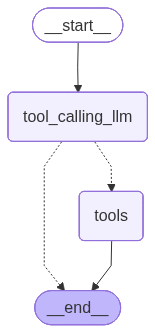

In [61]:
### Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call → tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call → tools_condition routes to END
    tools_condition,
)

builder.add_edge("tools",END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [62]:
messages = graph.invoke({"messages":"1706.03762"})

for m in messages['messages']:
    m.pretty_print()

================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [63]:
messages = graph.invoke({"messages":"Hi my name is saif, how are you"})

for m in messages['messages']:
    m.pretty_print()

================================== Ai Message ==================================

I'm functioning properly, thank you for asking. How can I assist you today?


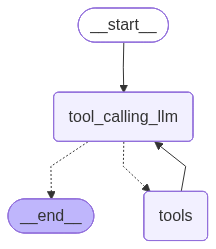

In [64]:
### Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call → tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call → tools_condition routes to END
    tools_condition,
)

builder.add_edge("tools", "tool_calling_llm")

builder.add_edge("tools",END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))